# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading the dataset

In [8]:
data = pd.read_csv("Preprocessed_dataset_knn(5neighbour).csv")
data.head()

/var/folders/lz/gg3608196pgcm29rnqq45xtm0000gn/T/ipykernel_78660/2482440009.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Preprocessed_dataset_knn(5neighbour).csv")


,Reporting Period,Project ID,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,...,Number Of Units,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
0,2023-06-30,577366,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,2023-06-22,9661.0,Oil,...,1,Home Performance,Single Family,Building Shell,277.0,24.0,6.826545,0,42.110115,-76.032545
1,2023-06-30,581070,Queens,Queens,11433,National Grid,Consolidated Edison,2023-06-22,11867.0,Natural Gas,...,1,Home Performance,Single Family,Building Shell,1062.0,66.0,7.221105,0,40.697715,-73.786045
2,2023-06-30,570945,Oswego,Fulton,13069,National Grid,National Grid,2023-06-20,9998.0,Natural Gas,...,1,Home Performance,Single Family,Building Shell,59.0,60.0,6.489205,0,43.325035,-76.411740
3,2023-06-30,571921,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,2023-06-13,6880.0,Oil,...,1,Home Performance,Single Family,Building Shell,482.0,15.0,6.445720,0,44.695165,-74.704765
4,2023-06-30,555646,Oswego,Cleveland,13042,National Grid,National Grid,2023-06-13,12289.0,Oil,...,1,Home Performance,Single Family,Building Shell,690.0,78.0,7.490529,0,43.231255,-75.868192


In [9]:
data.describe()

,Project ZIP,Total Project Cost,Year Home Built,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
count,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51930.000000,51934.0,51934.000000,51934.000000
mean,13263.577695,6432.440848,1948.107868,1572.731717,1.058074,469.881330,31.389013,5.853971,0.0,42.488912,-76.116195
std,1300.423594,4154.131692,29.295404,627.668989,2.175599,1095.349244,27.025809,0.875141,0.0,0.970511,1.834420
min,10001.000000,129.000000,1790.000000,800.000000,1.000000,-23368.000000,-80.000000,0.000000,0.0,40.542400,-79.745086
25%,12458.000000,3742.000000,1931.000000,1111.000000,1.000000,158.000000,14.000000,5.356586,0.0,42.084960,-77.636890
50%,13492.000000,5926.000000,1948.000000,1440.000000,1.000000,443.000000,26.000000,5.957131,0.0,42.929765,-76.112650
75%,14424.000000,8462.000000,1966.000000,1874.000000,1.000000,536.000000,43.000000,6.444131,0.0,43.133750,-74.044827
max,14905.000000,92297.000000,2022.000000,4000.000000,396.000000,38572.000000,1005.000000,10.199547,0.0,44.989856,-72.186670


# Checking for null values

In [13]:
data.isnull().sum()

Reporting Period                                        0
Project ID                                              0
Project County                                          0
Project City                                            0
Project ZIP                                             0
Gas Utility                                             0
Electric Utility                                        0
Project Completion Date                                 0
Total Project Cost                                      0
Pre-Retrofit Home Heating Fuel Type                     0
Year Home Built                                         0
Size Of Home                                            0
Number Of Units                                         0
Job Type                                                0
Type Of Dwelling                                        0
Measure Type                                            0
Estimated Annual kWh Savings                            0
Estimated Annu

In [17]:
data[data['First Year Modeled Project Energy Savings $ Estimate'].isnull()]

,Reporting Period,Project ID,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,...,Number Of Units,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
9344,2023-06-30,526609,Greene,Durham,12422,Central Hudson Gas & Electric,Central Hudson Gas & Electric,2022-02-22,14050.0,Wood,...,1,Home Performance,Single Family,Building Shell,0.0,25.0,NaN,0,42.385039,-74.239831
10239,2023-06-30,523636,Oneida,Utica,13502,National Grid,National Grid,2022-04-27,2920.0,Oil,...,1,Home Performance,Single Family,Building Shell,1039.0,-10.0,NaN,0,43.101082,-75.247273
17458,2023-06-30,532820,Warren,Queensbury,12804,National Grid,National Grid,2022-02-24,3139.0,Natural Gas,...,1,Home Performance,Mobile,Building Shell,-2023.0,12.0,NaN,0,43.334710,-73.678785
23910,2023-06-30,496242,Otsego,Cooperstown,13326,New York State Electric & Gas,New York State Electric & Gas,2021-12-28,6010.0,Other,...,1,Home Performance,Single Family,Building Shell,510.0,-4.0,NaN,0,42.698717,-74.928102


## Dropping null value

In [24]:
data.shape

(51930, 22)

In [21]:
data.dropna(inplace= True)

In [22]:
data.isnull().sum()

Reporting Period                                        0
Project ID                                              0
Project County                                          0
Project City                                            0
Project ZIP                                             0
Gas Utility                                             0
Electric Utility                                        0
Project Completion Date                                 0
Total Project Cost                                      0
Pre-Retrofit Home Heating Fuel Type                     0
Year Home Built                                         0
Size Of Home                                            0
Number Of Units                                         0
Job Type                                                0
Type Of Dwelling                                        0
Measure Type                                            0
Estimated Annual kWh Savings                            0
Estimated Annu

In [25]:
data.shape

(51930, 22)

# Checking Data type and dropping columns which are not important based on domain knowledge

In [26]:
data.dtypes

Reporting Period                                         object
Project ID                                               object
Project County                                           object
Project City                                             object
Project ZIP                                               int64
Gas Utility                                              object
Electric Utility                                         object
Project Completion Date                                  object
Total Project Cost                                      float64
Pre-Retrofit Home Heating Fuel Type                      object
Year Home Built                                           int64
Size Of Home                                              int64
Number Of Units                                           int64
Job Type                                                 object
Type Of Dwelling                                         object
Measure Type                            

In [ ]:
data['Reporting Period'].value_counts() 

Reporting Period
2023-06-30    51930
Name: count, dtype: int64

### Since the Reporting period is same for all the records dropping it 

In [31]:
data['Project ID'].describe()

count      51930
unique     51803
top       473112
freq           2
Name: Project ID, dtype: int64

### Dropping project Id has it doesn't matter for projected annual savings, the project ID acts an identifier only for the project work and won't be useful for the savings predictions

In [40]:
drop_columns_list = ['Reporting Period','Project ID']
data.drop(columns = drop_columns_list, inplace= True)

In [41]:
data.head()

,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
0,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,2023-06-22,9661.0,Oil,1960,1484,1,Home Performance,Single Family,Building Shell,277.0,24.0,6.826545,0,42.110115,-76.032545
1,Queens,Queens,11433,National Grid,Consolidated Edison,2023-06-22,11867.0,Natural Gas,1933,1664,1,Home Performance,Single Family,Building Shell,1062.0,66.0,7.221105,0,40.697715,-73.786045
2,Oswego,Fulton,13069,National Grid,National Grid,2023-06-20,9998.0,Natural Gas,1944,1252,1,Home Performance,Single Family,Building Shell,59.0,60.0,6.489205,0,43.325035,-76.411740
3,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,2023-06-13,6880.0,Oil,1913,1700,1,Home Performance,Single Family,Building Shell,482.0,15.0,6.445720,0,44.695165,-74.704765
4,Oswego,Cleveland,13042,National Grid,National Grid,2023-06-13,12289.0,Oil,1901,2680,1,Home Performance,Single Family,Building Shell,690.0,78.0,7.490529,0,43.231255,-75.868192


# changing datatypes and create new feature date column

In [81]:
data.dtypes

Project County                                           object
Project City                                             object
Project ZIP                                               int64
Gas Utility                                              object
Electric Utility                                         object
Project Completion Date                                  object
Total Project Cost                                      float64
Pre-Retrofit Home Heating Fuel Type                      object
Year Home Built                                           int64
Size Of Home                                              int64
Number Of Units                                           int64
Job Type                                                 object
Type Of Dwelling                                         object
Measure Type                                             object
Estimated Annual kWh Savings                            float64
Estimated Annual MMBtu Savings          

In [83]:
data["Project Completion Date"] = pd.to_datetime(data['Project Completion Date'], format="%Y-%m-%d")

In [84]:
import datetime as dt
data["Project Completion year"] = data['Project Completion Date'].dt.year
data["Project Completion month"] = data['Project Completion Date'].dt.month
data["Project Completion day"] = data['Project Completion Date'].dt.day

In [85]:
data.drop(columns = "Project Completion Date" , inplace = True)
data.head()

,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,...,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion year,Project Completion month,Project Completion day
0,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1960,1484,1,...,Building Shell,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22
1,Queens,Queens,11433,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,...,Building Shell,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22
2,Oswego,Fulton,13069,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,...,Building Shell,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20
3,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,6880.0,Oil,1913,1700,1,...,Building Shell,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13
4,Oswego,Cleveland,13042,National Grid,National Grid,12289.0,Oil,1901,2680,1,...,Building Shell,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13


# EDA

# Univariate

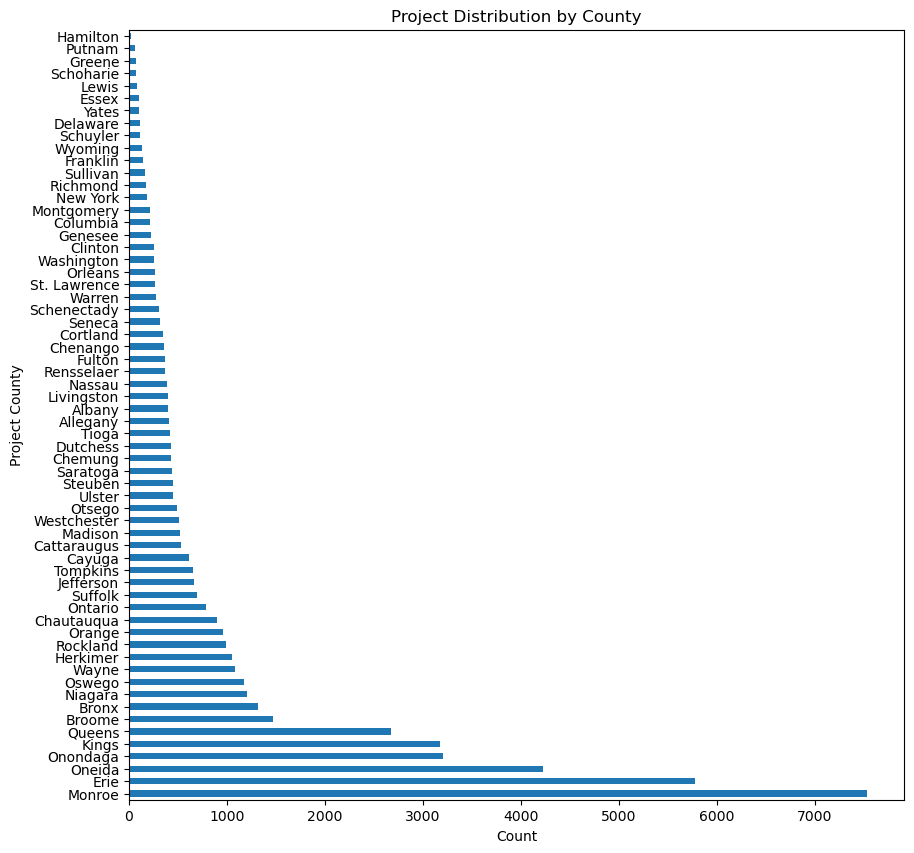

In [54]:
project_county_info = data['Project County'].value_counts()
project_county_info.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Count')
plt.title('Project Distribution by County')
plt.show()

In [80]:
value = data['Project County'].value_counts().head(15)
sum = 0
for i in value:
    sum += i
total_percentage = (sum/len(data)) * 100
county_count = len(data["Project County"].unique())
print(f"15 counties consists of {round(total_percentage,2)}% in the dataset")
print(f"The number of counties involved in the dataset are {county_count}")

15 counties consists of 70.71% in the dataset
The number of counties involved in the dataset are 62


## Findings 1
1. 15 counties consists of 70.71% in the dataset
2. The number of counties involved in the dataset are 62

In [86]:
data.dtypes

Project County                                           object
Project City                                             object
Project ZIP                                               int64
Gas Utility                                              object
Electric Utility                                         object
Total Project Cost                                      float64
Pre-Retrofit Home Heating Fuel Type                      object
Year Home Built                                           int64
Size Of Home                                              int64
Number Of Units                                           int64
Job Type                                                 object
Type Of Dwelling                                         object
Measure Type                                             object
Estimated Annual kWh Savings                            float64
Estimated Annual MMBtu Savings                          float64
First Year Modeled Project Energy Saving

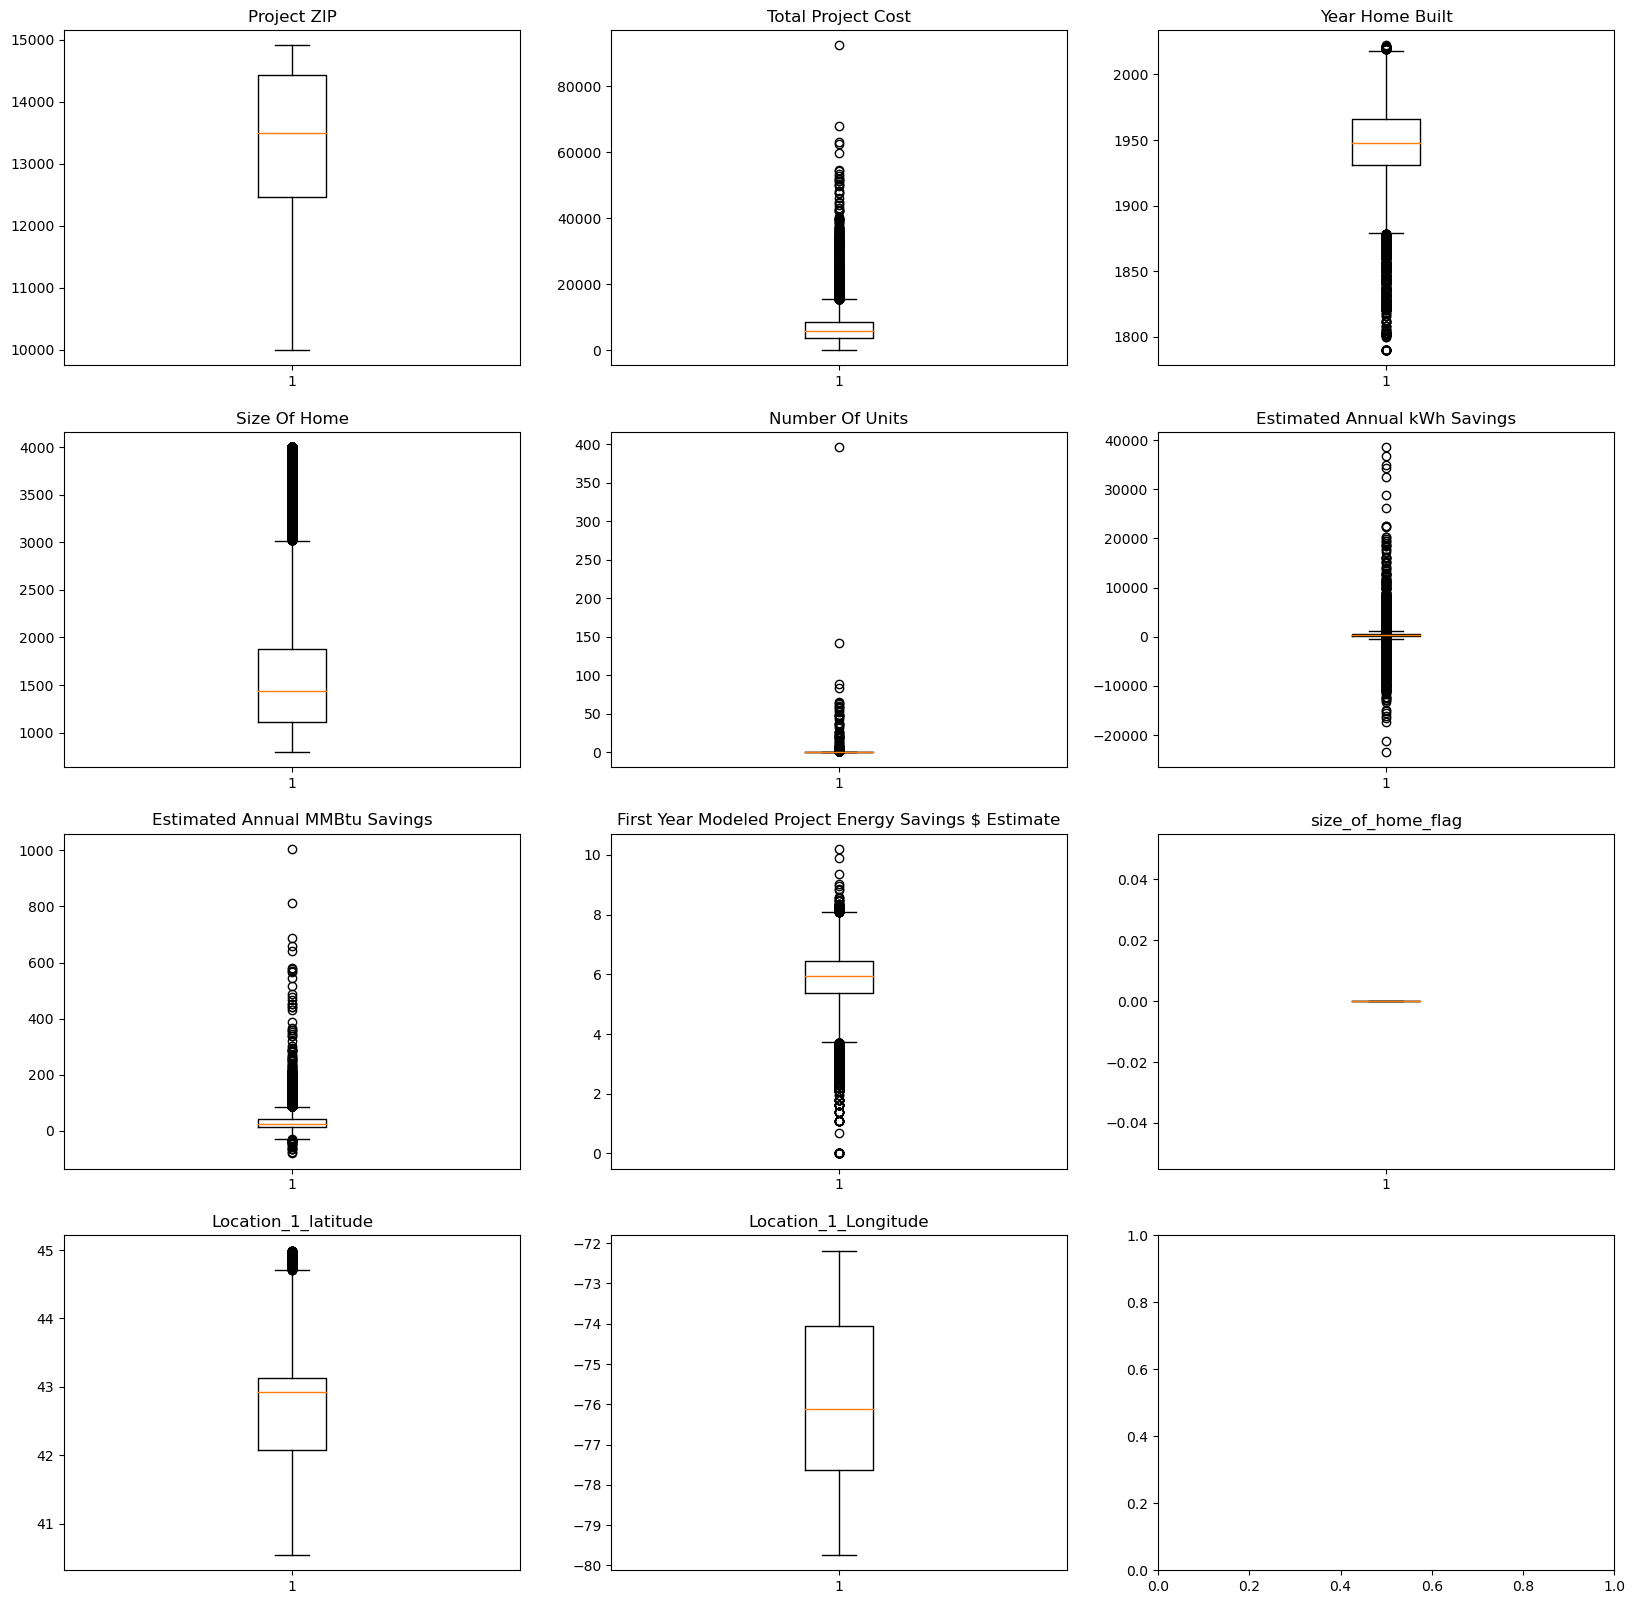

In [97]:
num_col = data.select_dtypes(include=["int64","float64"]).columns.tolist()
num_col
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(num_col):
    axes[i].boxplot(data[col])
    axes[i].set_title(col)

## Findings 2

1. Project ZIP Code acts as a categorical geographical identifier rather than a numerical feature, and therefore should not be treated as a continuous variable for modeling purposes.

2. Total Project Cost exhibits strong right skewness with significant high-value outliers, indicating that a small number of expensive projects dominate the distribution.

3. The majority of homes were built between 1900 and 2000, suggesting that the dataset primarily consists of mid-aged residential properties.

4. Estimated Annual Savings (kWh and MMBtu) show a wide spread with extreme outliers on both ends, including negative values, indicating high variability and potential modeling noise.

5. Even after applying a log(x+1) transformation, the First Year Modeled Project Energy Savings ($) variable still exhibits left-tail deviations, suggesting the persistence of lower-end outliers and the need for robust modeling techniques.

# *I think need to create new feature columns to create more stronger linear models*
*wide variance may show that there is nonlinear relationship*